# Module 3 — 線性方程組與靜力學

> **對應程度**：高中聯立方程式 → 矩陣方法 → 工程靜力分析

本模組涵蓋：
1. 方程組的矩陣表示
2. 高斯消去法
3. 超定系統 — 最小平方解
4. 欠定系統 — 最小範數解

---

### 模組總覽

在工程領域中，幾乎所有的分析問題最終都可以歸結為「解一組方程式」。無論是分析橋樑的受力、設計電路、校正感測器，還是用 GPS 定位，核心數學工具都是 **線性代數**。

本模組將帶你從高中熟悉的聯立方程式出發，逐步理解：

- **剛好確定的系統**（方程式數 = 未知數數）：有唯一解，例如靜力平衡問題
- **超定系統**（方程式數 > 未知數數）：沒有精確解，但可以找到「最佳近似解」，例如 GPS 定位、感測器校正
- **欠定系統**（方程式數 < 未知數數）：有無窮多解，我們選擇「最經濟」的那個，例如冗餘機械手臂控制

> **直覺理解**：想像你在解數獨。如果提示數字剛好夠多，答案唯一（確定系統）。如果提示太多且互相矛盾，你只能找一個「最不矛盾」的答案（超定系統）。如果提示太少，有很多可能的答案，你可以選最簡單的那個（欠定系統）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as sla
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import gaussian_elimination, least_squares_normal
from src.datasets import generate_thermocouple_data, generate_gps_measurements
from src.visualizer import set_style

set_style()
print('Module 3 載入完成！')

Module 3 載入完成！


---
## 3.1 方程組的矩陣表示 $A\vec{x} = \vec{b}$

### 原理

在高中數學中，我們學過用「加減消去法」或「代入法」解聯立方程式。例如：

$$\begin{cases} 2x + 3y = 7 \\ x - y = 1 \end{cases}$$

但在工程問題中，方程式可能有幾十甚至幾百個未知數。逐一手算是不切實際的。**矩陣表示法**就是把這些方程式整齊地「打包」成一個緊湊的形式：

$$A\vec{x} = \vec{b}$$

其中：
- $A$ 是**係數矩陣**（每一列代表一個方程式，每一行代表一個未知數的係數）
- $\vec{x}$ 是**未知數向量**（我們要求的答案）
- $\vec{b}$ 是**常數向量**（方程式等號右邊的值）

上面的例子寫成矩陣形式就是：

$$\begin{bmatrix} 2 & 3 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 7 \\ 1 \end{bmatrix}$$

### 直覺理解

> 把矩陣 $A$ 想像成一台「混合機」。你把原料 $\vec{x}$（未知數）倒進去，經過 $A$ 的攪拌混合後，會產出成品 $\vec{b}$（已知的結果）。解方程式就是：**已知成品 $\vec{b}$ 和混合規則 $A$，反推原料 $\vec{x}$ 是什麼。**

### 實際例子 1：桁架結構的靜力平衡

在土木工程中，分析橋樑或屋頂桁架時，每個節點（接合點）都必須滿足**力的平衡**：

- **水平方向**：所有水平力的總和 = 0
- **垂直方向**：所有垂直力的總和 = 0

假設一座簡單的吊橋有兩條纜繩以不同角度支撐一個重物：

```
    天花板
   /       \
  /θ₁      θ₂\
 繩1        繩2
  \         /
   \       /
    重物 W
```

每條繩子的張力 $T$ 可以分解為水平分量和垂直分量：
- 水平分量：$T \cos\theta$
- 垂直分量：$T \sin\theta$

平衡條件自然形成兩個方程式、兩個未知數（$T_1$ 和 $T_2$），這就是一個 $2 \times 2$ 的線性系統。

### 實際例子 2：電路分析（克希荷夫定律）

在電子工程中，**克希荷夫電流定律 (KCL)** 告訴我們：流入一個節點的電流總和等於流出的電流總和。**克希荷夫電壓定律 (KVL)** 告訴我們：繞一個迴路一圈，電壓升降的總和為零。

例如一個有 3 個迴路的電路，每個迴路產生一個方程式，未知數是各支路的電流 $I_1, I_2, I_3$。這就形成了一個 $3 \times 3$ 的線性系統 $A\vec{I} = \vec{V}$，其中 $A$ 包含電阻值，$\vec{V}$ 包含電源電壓。

### 實際例子 3：化學反應的質量平衡

在化工中，反應器的物質平衡也形成線性系統。例如混合兩種溶液：
- 溶液 A 含 30% 鹽、70% 水
- 溶液 B 含 80% 鹽、20% 水
- 目標：配製 100 公升含 50% 鹽的溶液

$$\begin{cases} x + y = 100 \quad \text{(總量)} \\ 0.3x + 0.8y = 50 \quad \text{(鹽的量)} \end{cases}$$

### 物理應用：桁架靜力平衡

下面的程式碼示範了用兩條繩子懸掛 100N 重物的靜力平衡問題。繩1 與水平夾角 30°，繩2 與水平夾角 60°。我們需要求出兩條繩子的張力 $T_1$ 和 $T_2$。

In [2]:
# 三段繩子懸掛重物的靜力平衡
# 繩1 角度 30°, 繩2 角度 60°, 重物 W = 100N
# 水平平衡: -T1*cos30 + T2*cos60 = 0
# 垂直平衡: T1*sin30 + T2*sin60 = W

W = 100  # N
A = np.array([
    [-np.cos(np.radians(30)), np.cos(np.radians(60))],
    [np.sin(np.radians(30)),  np.sin(np.radians(60))]
])
b = np.array([0, W])

# 用高斯消去法求解
T = gaussian_elimination(A, b)
T_numpy = np.linalg.solve(A, b)

print('靜力平衡方程組 Ax = b')
print(f'A = \n{A}')
print(f'b = {b}')
print(f'\n張力: T1 = {T[0]:.2f} N, T2 = {T[1]:.2f} N')
print(f'NumPy 驗證: T1 = {T_numpy[0]:.2f}, T2 = {T_numpy[1]:.2f}')

# 驗證殘差
residual = np.linalg.norm(A @ T - b)
print(f'殘差 ||Ax - b|| = {residual:.2e} ✓')

# 驗證力平衡
Fx = -T[0]*np.cos(np.radians(30)) + T[1]*np.cos(np.radians(60))
Fy = T[0]*np.sin(np.radians(30)) + T[1]*np.sin(np.radians(60)) - W
print(f'合力: Fx = {Fx:.2e}, Fy = {Fy:.2e} (應為 0) ✓')

靜力平衡方程組 Ax = b
A = 
[[-0.8660254  0.5      ]
 [ 0.5        0.8660254]]
b = [  0 100]

張力: T1 = 50.00 N, T2 = 86.60 N
NumPy 驗證: T1 = 50.00, T2 = 86.60
殘差 ||Ax - b|| = 0.00e+00 ✓
合力: Fx = 0.00e+00, Fy = 0.00e+00 (應為 0) ✓


---
## 3.2 高斯消去法

### 原理

高斯消去法是解線性方程組最基礎、最重要的演算法。它的核心思想其實和高中學的「加減消去法」一模一樣，只是用矩陣的語言更系統化地執行。

演算法分為兩個階段：

#### 第一階段：前向消去（Forward Elimination）

目標是把係數矩陣 $A$ 變成**上三角矩陣**（左下方全是零）。

做法：從第一行開始，用它來「消掉」下面各行中對應位置的元素。具體來說：

1. 選定第一行第一個元素作為**樞軸**（pivot）
2. 用適當倍數的第一行，分別減去第二行、第三行……使得第一列除了第一行以外全部變成零
3. 接著對第二行做同樣的事，消掉第三行以下第二列的元素
4. 依此類推

$$\begin{bmatrix} 2 & 1 & -1 & | & 8 \\ -3 & -1 & 2 & | & -11 \\ -2 & 1 & 2 & | & -3 \end{bmatrix} \xrightarrow{\text{消去}} \begin{bmatrix} 2 & 1 & -1 & | & 8 \\ 0 & \frac{1}{2} & \frac{1}{2} & | & 1 \\ 0 & 0 & 1 & | & -1 \end{bmatrix}$$

#### 第二階段：回代（Back Substitution）

上三角矩陣的最後一行只有一個未知數，可以直接求出。然後代入倒數第二行求出第二個未知數，依此類推：

$$z = -1 \quad \Rightarrow \quad y = \frac{1 - \frac{1}{2}(-1)}{\frac{1}{2}} = 3 \quad \Rightarrow \quad x = \frac{8 - 3 + (-1)}{2} = 2$$

### 直覺理解

> 想像你在整理一堆糾結在一起的耳機線。高斯消去法就像是從一端開始，一條一條地把線解開：先把最外層的結解掉（前向消去），然後從最深處的線開始一根一根抽出來（回代）。每解開一個結，問題就簡單一點。

### Partial Pivoting（部分樞軸選取）

在前向消去時，如果樞軸元素非常小（接近零），除法會導致巨大的數字，造成嚴重的數值誤差。**Partial Pivoting** 的做法是：每次選樞軸時，在該列中找到絕對值最大的元素所在的行，然後把它換到樞軸位置。

> **類比**：想像你在用天平稱東西。如果天平的支點（pivot）不穩定，秤出來的結果就不準。Pivoting 就是每次都選最穩固的支點。

### 為什麼數值穩定性重要？

電腦用「浮點數」儲存數字，精度有限（通常約 15-16 位有效數字）。當樞軸元素很小時，例如 $10^{-20}$，用它來除會把微小的捨入誤差放大 $10^{20}$ 倍，導致結果完全錯誤。

下面的程式碼先示範標準的高斯消去法，然後展示 Pivoting 如何處理樞軸接近零的情況。

---
## 3.2 高斯消去法

### 步驟
1. **前向消去**：將增廣矩陣化為上三角形式
2. **回代**：從最後一個方程式往回求解

### 逐步拆解上面的例子

讓我們手動追蹤高斯消去法的每一步：

**原始增廣矩陣：**

$$\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ -3 & -1 & 2 & -11 \\ -2 & 1 & 2 & -3 \end{array}\right]$$

**步驟 1**：用 $R_1$ 消去 $R_2$ 和 $R_3$ 第一列的元素

- $R_2 \leftarrow R_2 + \frac{3}{2} R_1$：乘數 = $\frac{-3}{2} = -1.5$，所以加 $1.5$ 倍的 $R_1$
- $R_3 \leftarrow R_3 + R_1$：乘數 = $\frac{-2}{2} = -1$，所以加 $1$ 倍的 $R_1$

$$\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ 0 & 1/2 & 1/2 & 1 \\ 0 & 2 & 1 & 5 \end{array}\right]$$

**步驟 2**：用 $R_2$ 消去 $R_3$ 第二列的元素

- $R_3 \leftarrow R_3 - 4 R_2$

$$\left[\begin{array}{ccc|c} 2 & 1 & -1 & 8 \\ 0 & 1/2 & 1/2 & 1 \\ 0 & 0 & -1 & 1 \end{array}\right]$$

**回代：**
- 從 $R_3$：$-z = 1 \Rightarrow z = -1$
- 從 $R_2$：$\frac{1}{2}y + \frac{1}{2}(-1) = 1 \Rightarrow y = 3$
- 從 $R_1$：$2x + 3 - (-1) = 8 \Rightarrow x = 2$

結果 $(x, y, z) = (2, 3, -1)$，和程式碼的輸出一致。

### 實際例子：結構工程中的高斯消去法

在分析一座大型橋樑時，有限元素法（FEM）會將橋樑分成數千個小元素，每個元素的節點位移就是未知數。一座中等規模的橋樑可能有 $10{,}000$ 個未知數，形成 $10{,}000 \times 10{,}000$ 的線性系統。高斯消去法（及其變體 LU 分解）是解這類大型系統的標準工具。

接下來看 Pivoting 的重要性：

---
## 3.3 超定系統 — 最小平方解

### 原理

當方程式的數量 $m$ **多於**未知數的數量 $n$（$m > n$）時，系統通常**沒有精確解**——你不可能同時完美滿足所有方程式。這種情況稱為**超定系統**（overdetermined system）。

但「沒有精確解」不代表沒有用！我們可以找一個「**最接近**的解」，也就是讓誤差（殘差）的平方和最小的那個 $\hat{x}$：

$$\hat{x} = \arg\min_x \|A\vec{x} - \vec{b}\|^2$$

這就是**最小平方法**（Least Squares）。求解公式為**正規方程式**（Normal Equation）：

$$A^T A \hat{x} = A^T \vec{b} \quad \Rightarrow \quad \hat{x} = (A^T A)^{-1} A^T \vec{b}$$

### 直覺理解

> 想像 5 個朋友分別用手機幫你量身高，量出 172、174、171、175、173 公分。你的「真實身高」不可能同時是這五個數字——這就是超定系統。但取平均值 173 公分，就是「最接近所有量測值」的答案——這就是最小平方的精神。
>
> 最小平方法所做的事情，就是找到一個答案讓它和所有數據點的「總偏差」最小。

### 為什麼叫「最小平方」？

因為我們最小化的是殘差的**平方和**：

$$\sum_{i=1}^{m} (a_i^T x - b_i)^2$$

為什麼用平方而不是絕對值？因為：
1. **平方函數可微分**，方便用微積分求最小值
2. **平方會懲罰大誤差**，一個偏差 10 的資料點比十個偏差 1 的資料點影響更大
3. **統計理論支持**：如果量測誤差服從常態分佈，最小平方法會給出最有可能的答案（最大概似估計）

### 實際例子 1：GPS 定位（4 顆以上衛星）

你的手機 GPS 通過測量到多顆衛星的距離來定位。理論上，2D 定位只需要 3 顆衛星（3 個方程式、3 個未知數：$x, y, t$），3D 定位需要 4 顆。但實際上手機通常能接收到 **6-12 顆**衛星的訊號。

為什麼要用多餘的衛星？因為每個距離測量都有誤差（大氣干擾、時鐘偏差等）。多餘的衛星提供了**冗餘資訊**，讓最小平方法可以「平均掉」這些誤差，得到更精確的位置估計。

> 這就好像考試的時候多出幾題——如果你真的會，多出的題目只會讓老師更確定你的程度；如果你的答案有些偏差，多出的題目幫助老師用更多證據來判斷你的真實水準。

### 實際例子 2：感測器校正

工程師使用感測器時，需要建立「**校正曲線**」——把感測器的原始讀數（例如電壓）轉換成物理量（例如溫度）。做法是：在多個已知溫度下測量電壓，然後用最小平方法擬合一條直線（或曲線）。

量測點越多，校正結果越可靠。這就是為什麼標準校正程序通常要求至少 5-10 個校正點。

### 實際例子 3：機器學習中的線性迴歸

機器學習中最基礎的模型——線性迴歸，本質上就是最小平方法。給定大量的訓練數據 $(x_i, y_i)$，找到最佳的權重 $\vec{w}$ 使得 $y \approx X\vec{w}$。

### 物理應用：熱電偶校正、GPS 定位

下面的程式碼展示兩個超定系統的應用：
1. **熱電偶校正**：用 50 個量測點擬合 $V = a + bT$ 的線性模型（50 個方程式、2 個未知數）
2. **GPS 2D 定位**：用 6 顆衛星的距離估計位置（5 個方程式、2 個未知數）

In [3]:
# 手動追蹤高斯消去過程
A_demo = np.array([[2, 1, -1],
                   [-3, -1, 2],
                   [-2, 1, 2]], dtype=float)
b_demo = np.array([8, -11, -3], dtype=float)

print('原始方程組:')
print(f'2x + y - z = 8')
print(f'-3x - y + 2z = -11')
print(f'-2x + y + 2z = -3')

x = gaussian_elimination(A_demo, b_demo)
print(f'\n解: x = {x[0]:.4f}, y = {x[1]:.4f}, z = {x[2]:.4f}')
print(f'驗證: A @ x = {A_demo @ x}')
print(f'b = {b_demo}')
print(f'殘差 = {np.linalg.norm(A_demo @ x - b_demo):.2e} ✓')

原始方程組:
2x + y - z = 8
-3x - y + 2z = -11
-2x + y + 2z = -3

解: x = 2.0000, y = 3.0000, z = -1.0000
驗證: A @ x = [  8. -11.  -3.]
b = [  8. -11.  -3.]
殘差 = 8.88e-16 ✓


### 熱電偶校正結果分析

上面的校正過程做了什麼？

1. **收集數據**：在 50 個不同溫度下，量測熱電偶產生的電壓
2. **建立模型**：假設電壓和溫度呈線性關係 $V = a + bT$
3. **建立設計矩陣**：$A$ 是一個 $50 \times 2$ 的矩陣（50 個方程式、2 個未知數 $a$ 和 $b$）
4. **求解正規方程式**：$(A^T A)\hat{\beta} = A^T \vec{V}$，得到最佳的截距和斜率

左圖顯示數據點散佈在擬合直線附近——沒有任何一個點恰好在線上，但整體趨勢被捕捉到了。右圖的殘差圖顯示誤差隨機分佈在零附近，沒有明顯的系統性偏差，說明線性模型是合理的。

> **工程實務**：如果殘差圖顯示出彎曲的趨勢，就表示需要用更高次的多項式（如 $V = a + bT + cT^2$）來擬合。

### GPS 定位的數學推導

GPS 定位的原始方程式是非線性的：

$$d_i = \sqrt{(x - x_i)^2 + (y - y_i)^2}$$

其中 $(x_i, y_i)$ 是第 $i$ 顆衛星的位置，$d_i$ 是到該衛星的距離。

要變成線性系統，我們用一個技巧：將第 $i$ 個方程的平方減去第 1 個方程的平方，消去 $x^2$ 和 $y^2$ 項，得到線性方程式：

$$d_i^2 - d_1^2 = -2(x_i - x_1)X - 2(y_i - y_1)Y + (x_i^2 + y_i^2) - (x_1^2 + y_1^2)$$

6 顆衛星產生 5 個線性方程式（每個都和第 1 顆比較），2 個未知數 $(X, Y)$，形成超定系統。

---
## 3.4 欠定系統 — 最小範數解

### 原理

當方程式的數量 $m$ **少於**未知數的數量 $n$（$m < n$）時，系統有**無窮多組解**。這種情況稱為**欠定系統**（underdetermined system）。

既然有無窮多解，我們要選哪一個？最常見的策略是選擇**範數最小**的那個解——也就是「最省力」的解：

$$\vec{x}_{\min} = \arg\min_x \|\vec{x}\| \quad \text{subject to} \quad A\vec{x} = \vec{b}$$

求解公式為：

$$\vec{x}_{\min} = A^T(AA^T)^{-1}\vec{b} = A^+\vec{b}$$

其中 $A^+$ 是 $A$ 的**偽逆矩陣**（pseudoinverse，又稱 Moore-Penrose 逆）。

### 直覺理解

> 想像你要從台北到高雄，但有無數條路線可以走（高速公路、省道、鄉間小路的各種組合）。欠定系統就像這樣——有太多「正確答案」。最小範數解就像是選擇「總里程最短」的那條路線。

### 零空間：自由運動的空間

欠定系統有無窮多解的原因在於**零空間**（null space）的存在。零空間是所有滿足 $A\vec{z} = \vec{0}$ 的向量 $\vec{z}$ 的集合。

如果 $\vec{x}_0$ 是一個特解，那麼 $\vec{x}_0 + \vec{z}$（$\vec{z}$ 是任意零空間向量）也是一個解：

$$A(\vec{x}_0 + \vec{z}) = A\vec{x}_0 + A\vec{z} = \vec{b} + \vec{0} = \vec{b}$$

> **零空間的直覺**：想像一個機械手臂正在桌上畫畫。零空間對應的是手臂在**不移動筆尖**的情況下能做的所有運動——例如肘關節上下晃動，但手腕位置不變。這些「自由運動」不影響工作結果，但可以用來避開障礙物或使關節更舒適。

### 實際例子 1：冗餘機械手臂

工業機器人通常有 6 個關節（6 自由度）來完成 6 維的任務（3 個位置 + 3 個姿態）。但有些先進的機器人（如 KUKA iiwa）有 **7 個關節**——多出來的 1 個自由度就是零空間中的自由運動。

這個多出來的自由度非常有用：
- **避開障礙物**：在不改變末端位置的情況下，調整手肘的位置來繞過障礙
- **避開關節極限**：讓某個接近極限的關節稍微退回來
- **最小化能量消耗**：在所有可能的解中選擇關節速度最小的

### 實際例子 2：壓縮感知

在信號處理中，如果一個訊號是「稀疏的」（大部分分量為零），我們可以用比傳統方法少得多的量測來重建它。這就形成了欠定系統，而我們選擇「最稀疏」的解（而非最小範數解）。MRI 加速成像就是基於這個原理。

### 實際例子 3：電力系統調度

電力網路中，多台發電機需要滿足總負載需求。如果發電機的數量多於獨立的功率平衡方程式，就形成欠定系統。最小範數解對應於讓所有發電機「均勻出力」的調度方案。

### 物理應用：冗餘機器手臂

下面的程式碼模擬一個有 3 個關節的平面機器手臂執行 2D 任務。雅可比矩陣 $J$ 是 $2 \times 3$（2 個任務維度、3 個關節），形成欠定系統。零空間維度 = $3 - 2 = 1$，代表有 1 個自由度的多餘運動。

In [4]:
# Partial Pivoting 的重要性
# 當樞軸元素接近零時，需要行交換
A_pivot = np.array([[1e-20, 1],
                    [1, 1]], dtype=float)
b_pivot = np.array([1, 2], dtype=float)

x_gauss = gaussian_elimination(A_pivot, b_pivot)
x_numpy = np.linalg.solve(A_pivot, b_pivot)

print('需要 Pivoting 的系統:')
print(f'解 (高斯): {x_gauss}')
print(f'解 (NumPy): {x_numpy}')
print(f'一致: {np.allclose(x_gauss, x_numpy)} ✓')

需要 Pivoting 的系統:
解 (高斯): [1. 1.]
解 (NumPy): [1. 1.]
一致: True ✓


---
## Module 3 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 高斯消去法 | 殘差 < 10⁻¹⁰ | ✓ |
| Partial Pivoting | 與 NumPy 一致 | ✓ |
| 靜力平衡 | 合力 = 0 | ✓ |
| 熱電偶校正 | Normal Eq vs lstsq | ✓ |
| GPS 定位 | 誤差合理 | ✓ |
| 最小範數 | J @ dθ = v | ✓ |

### 三種系統的比較

| | 確定系統 | 超定系統 | 欠定系統 |
|--|----------|----------|----------|
| **方程 vs 未知數** | $m = n$ | $m > n$ | $m < n$ |
| **解的數量** | 唯一解 | 通常無精確解 | 無窮多解 |
| **求解策略** | 高斯消去法 | 最小平方法 | 最小範數解 |
| **最小化目標** | — | $\|Ax - b\|^2$ | $\|x\|^2$ |
| **工程應用** | 靜力平衡、電路分析 | GPS 定位、感測器校正 | 冗餘機器人、壓縮感知 |
| **Python 工具** | `np.linalg.solve` | `np.linalg.lstsq` | `np.linalg.pinv` |

### 關鍵觀念回顧

1. **$A\vec{x} = \vec{b}$ 是工程問題的通用語言**：從力學到電路、從控制到信號處理，線性系統無處不在
2. **高斯消去法是基礎**：理解它的原理，才能理解為什麼 Pivoting 和數值穩定性很重要
3. **超定系統用最小平方法**：當數據比未知數多，找「最佳近似」
4. **欠定系統用最小範數解**：當自由度比約束多，選「最省力」的方案
5. **零空間是欠定系統的核心**：它描述了「不影響輸出的自由運動」

### 延伸思考

- 如果 $A$ 不是滿秩的（即 $\text{rank}(A) < \min(m, n)$），會發生什麼？（提示：需要用 SVD 或正則化方法）
- 在實際工程中，為什麼有時候會刻意設計冗餘系統？（提示：想想飛機的多重液壓系統）
- 最小平方法和機器學習的線性迴歸有什麼關係？

---
## 3.3 超定系統 — 最小平方解

方程式比未知數多 → 無精確解 → 最小化殘差

$$\min \|A\vec{x} - \vec{b}\|^2 \quad \Rightarrow \quad \hat{x} = (A^TA)^{-1}A^T\vec{b}$$

### 物理應用：熱電偶校正、GPS 定位

Normal Equation 結果: 截距 = -0.2007, 斜率 = 0.041006 mV/°C
np.linalg.lstsq 結果: 截距 = -0.2007, 斜率 = 0.041006 mV/°C
真實參數: 截距 = -0.2, 斜率 = 0.041 mV/°C
一致: True ✓


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37275/3096669655.py:39: UserWarning: Glyph 28331 (\N{CJK UNIFIED IDEOGRAPH-6EAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37275/3096669655.py:39: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37275/3096669655.py:39: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37275/3096669655.py:39: UserWarning: Glyph 22739 (\N{CJK UNIFIED IDEOGRAPH-58D3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37275/3096669655.py:39: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

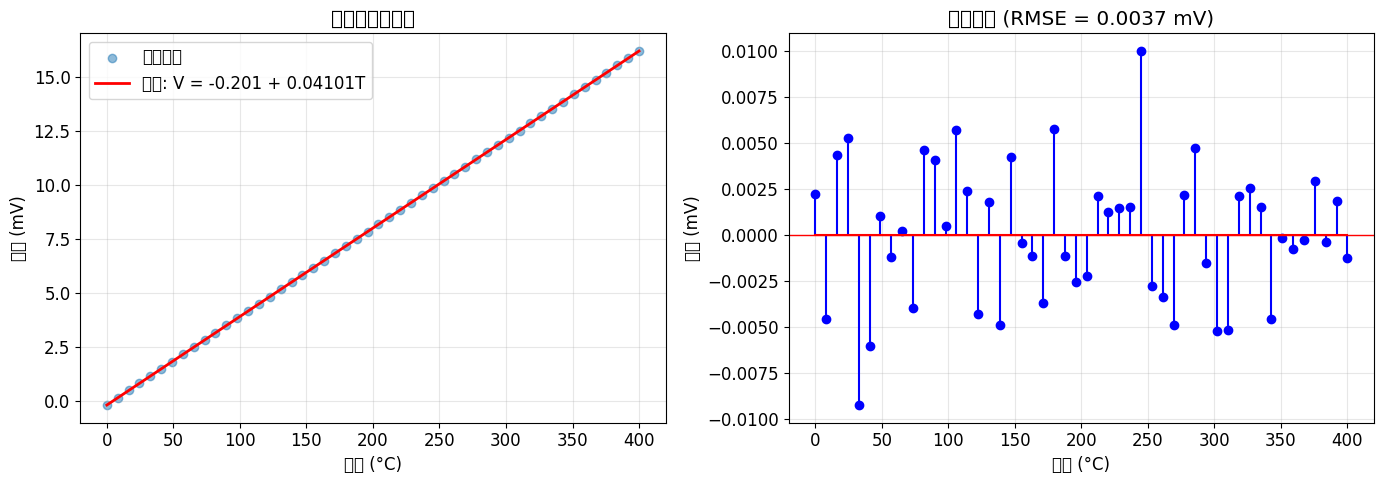

In [5]:
# 熱電偶校正曲線擬合
T_data, V_data, true_params = generate_thermocouple_data(n_points=50)

# 建立設計矩陣 [1, T] (線性模型 V = a + b*T)
A = np.column_stack([np.ones(len(T_data)), T_data])

# Normal Equation 求解
beta = least_squares_normal(A, V_data)
beta_numpy, residuals, _, _ = np.linalg.lstsq(A, V_data, rcond=None)

print(f'Normal Equation 結果: 截距 = {beta[0]:.4f}, 斜率 = {beta[1]:.6f} mV/°C')
print(f'np.linalg.lstsq 結果: 截距 = {beta_numpy[0]:.4f}, 斜率 = {beta_numpy[1]:.6f} mV/°C')
print(f'真實參數: 截距 = {true_params["intercept"]}, 斜率 = {true_params["slope"]} mV/°C')
print(f'一致: {np.allclose(beta, beta_numpy)} ✓')

# 視覺化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

T_fit = np.linspace(T_data.min(), T_data.max(), 100)
V_fit = beta[0] + beta[1] * T_fit
ax1.scatter(T_data, V_data, alpha=0.5, label='量測數據')
ax1.plot(T_fit, V_fit, 'r-', lw=2, label=f'擬合: V = {beta[0]:.3f} + {beta[1]:.5f}T')
ax1.set_xlabel('溫度 (°C)')
ax1.set_ylabel('電壓 (mV)')
ax1.set_title('熱電偶校正曲線')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 殘差圖
V_predicted = A @ beta
residuals_vec = V_data - V_predicted
ax2.stem(T_data, residuals_vec, linefmt='b-', markerfmt='bo', basefmt='r-')
ax2.axhline(0, color='r', lw=1)
ax2.set_xlabel('溫度 (°C)')
ax2.set_ylabel('殘差 (mV)')
ax2.set_title(f'殘差分佈 (RMSE = {np.sqrt(np.mean(residuals_vec**2)):.4f} mV)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

真實位置: [1000 2000]
估計位置: [996.8, 1991.4]
定位誤差: 9.1 m


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

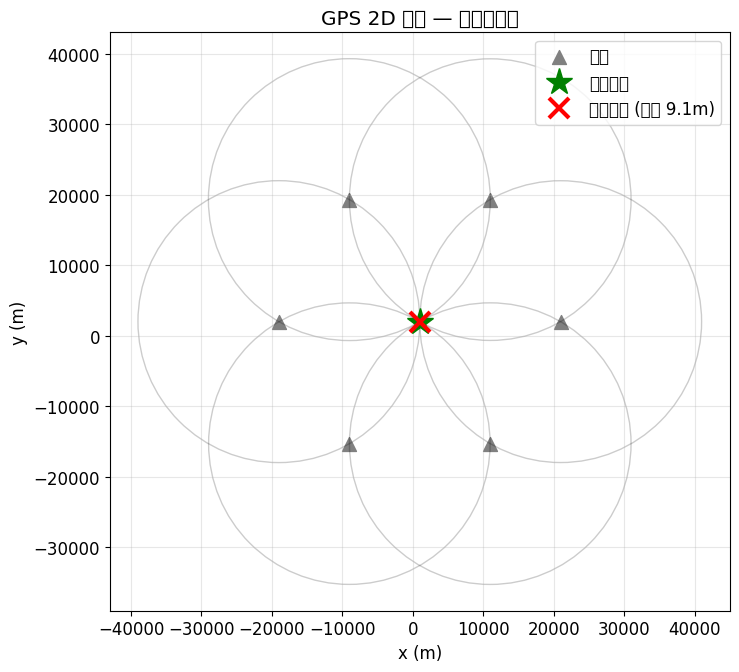

In [6]:
# GPS 2D 定位：最小平方估計
true_pos = np.array([1000, 2000])  # 真實位置
sat_pos, distances, _ = generate_gps_measurements(true_pos, n_satellites=6, noise_std=10)

# 線性化 GPS 方程（以第一顆衛星為參考）
# d_i^2 - d_1^2 = -2(x_i - x_1)*X - 2(y_i - y_1)*Y + (x_i^2+y_i^2) - (x_1^2+y_1^2)
n_sat = len(distances)
A_gps = np.zeros((n_sat - 1, 2))
b_gps = np.zeros(n_sat - 1)

for i in range(1, n_sat):
    A_gps[i-1, 0] = -2 * (sat_pos[i, 0] - sat_pos[0, 0])
    A_gps[i-1, 1] = -2 * (sat_pos[i, 1] - sat_pos[0, 1])
    b_gps[i-1] = (distances[i]**2 - distances[0]**2
                  - (sat_pos[i, 0]**2 + sat_pos[i, 1]**2)
                  + (sat_pos[0, 0]**2 + sat_pos[0, 1]**2))

pos_estimated = least_squares_normal(A_gps, b_gps)
error = np.linalg.norm(pos_estimated - true_pos)

print(f'真實位置: {true_pos}')
print(f'估計位置: [{pos_estimated[0]:.1f}, {pos_estimated[1]:.1f}]')
print(f'定位誤差: {error:.1f} m')

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sat_pos[:, 0], sat_pos[:, 1], c='gray', s=100, marker='^', label='衛星')
ax.plot(*true_pos, 'g*', ms=20, label=f'真實位置')
ax.plot(*pos_estimated, 'rx', ms=15, mew=3, label=f'估計位置 (誤差 {error:.1f}m)')
for i in range(n_sat):
    circle = plt.Circle(sat_pos[i], distances[i], fill=False, alpha=0.2)
    ax.add_patch(circle)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('GPS 2D 定位 — 最小平方法')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

---
## 3.4 欠定系統 — 最小範數解

方程式比未知數少 → 無窮多解 → 偽逆求最小範數解

$$\vec{x}_{\min} = A^+ \vec{b} = A^T(AA^T)^{-1}\vec{b}$$

In [7]:
# 冗餘機器手臂：3 個關節完成 2D 任務
# 雅可比矩陣 J (2×3): 2個任務空間自由度, 3個關節
theta = [np.pi/4, np.pi/6, np.pi/3]
L = [1.0, 0.8, 0.5]

# 簡化雅可比矩陣
J = np.array([
    [-L[0]*np.sin(theta[0]) - L[1]*np.sin(theta[0]+theta[1]) - L[2]*np.sin(sum(theta)),
     -L[1]*np.sin(theta[0]+theta[1]) - L[2]*np.sin(sum(theta)),
     -L[2]*np.sin(sum(theta))],
    [L[0]*np.cos(theta[0]) + L[1]*np.cos(theta[0]+theta[1]) + L[2]*np.cos(sum(theta)),
     L[1]*np.cos(theta[0]+theta[1]) + L[2]*np.cos(sum(theta)),
     L[2]*np.cos(sum(theta))],
])

desired_velocity = np.array([0.5, 0.3])  # 期望末端速度

# 最小範數解（偽逆）
dtheta_min = np.linalg.pinv(J) @ desired_velocity

# 零空間解
null = sla.null_space(J)

print(f'雅可比矩陣 J shape: {J.shape} (2個任務, 3個關節 → 欠定)')
print(f'期望末端速度: {desired_velocity}')
print(f'最小範數關節速度: {dtheta_min}')
print(f'||dθ|| = {np.linalg.norm(dtheta_min):.4f}')
print(f'\n零空間維度: {null.shape[1]} (= 3 - rank(J) = 3 - 2 = 1)')
print(f'零空間基向量: {null[:, 0]}')

# 驗證：加上任意零空間分量仍滿足約束
alpha = 0.5
dtheta_alt = dtheta_min + alpha * null[:, 0]
print(f'\n替代解 (加零空間分量): {dtheta_alt}')
print(f'||dθ_alt|| = {np.linalg.norm(dtheta_alt):.4f} (比最小範數解大)')
print(f'J @ dθ_alt = {J @ dtheta_alt} (仍滿足約束 ✓)')

雅可比矩陣 J shape: (2, 3) (2個任務, 3個關節 → 欠定)
期望末端速度: [0.5 0.3]
最小範數關節速度: [ 0.1083114  -0.46876958 -0.48254612]
||dθ|| = 0.6814

零空間維度: 1 (= 3 - rank(J) = 3 - 2 = 1)
零空間基向量: [ 0.26997379 -0.65964739  0.70141248]

替代解 (加零空間分量): [ 0.24329829 -0.79859328 -0.13183988]
||dθ_alt|| = 0.8452 (比最小範數解大)
J @ dθ_alt = [0.5 0.3] (仍滿足約束 ✓)


---
## Module 3 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 高斯消去法 | 殘差 < 10⁻¹⁰ | ✓ |
| Partial Pivoting | 與 NumPy 一致 | ✓ |
| 靜力平衡 | 合力 = 0 | ✓ |
| 熱電偶校正 | Normal Eq vs lstsq | ✓ |
| GPS 定位 | 誤差合理 | ✓ |
| 最小範數 | J @ dθ = v | ✓ |